In [ ]:
from google.colab import drive
drive.mount('/content/drive')

=== Dataset Overview ===
Shape: (5110, 12)

First 5 rows:
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1 

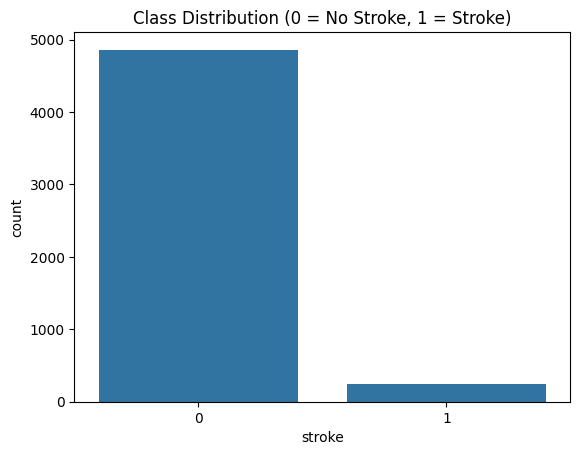

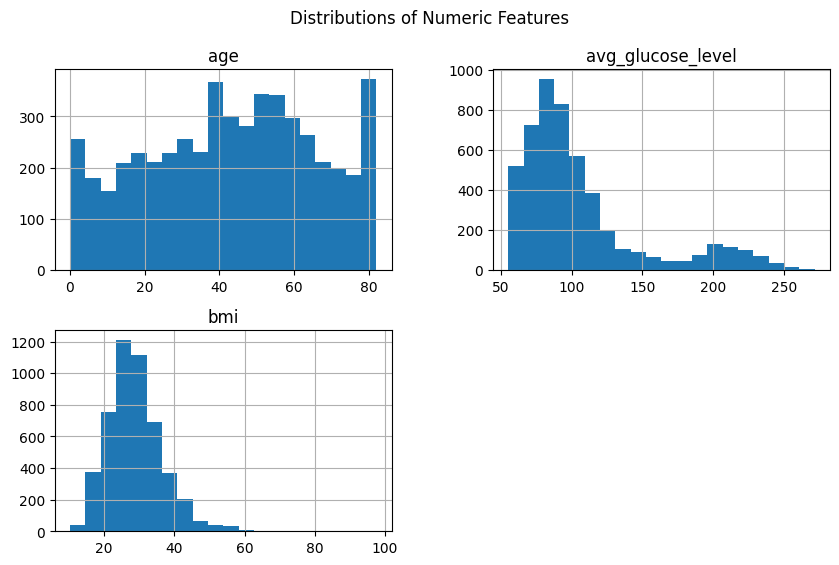

Correlation with 'stroke':
stroke                            1.000000
age                               0.245257
heart_disease                     0.134914
avg_glucose_level                 0.131945
hypertension                      0.127904
ever_married_Yes                  0.108340
smoking_status_formerly smoked    0.064556
work_type_Self-employed           0.062168
bmi                               0.042374
Residence_type_Urban              0.015458
work_type_Private                 0.011888
gender_Male                       0.009117
smoking_status_smokes             0.008939
work_type_Govt_job                0.002677
gender_Other                     -0.003166
smoking_status_never smoked      -0.004129
gender_Female                    -0.009027
work_type_Never_worked           -0.014882
Residence_type_Rural             -0.015458
smoking_status_Unknown           -0.055892
work_type_children               -0.083869
ever_married_No                  -0.108340
Name: stroke, dtype: float6

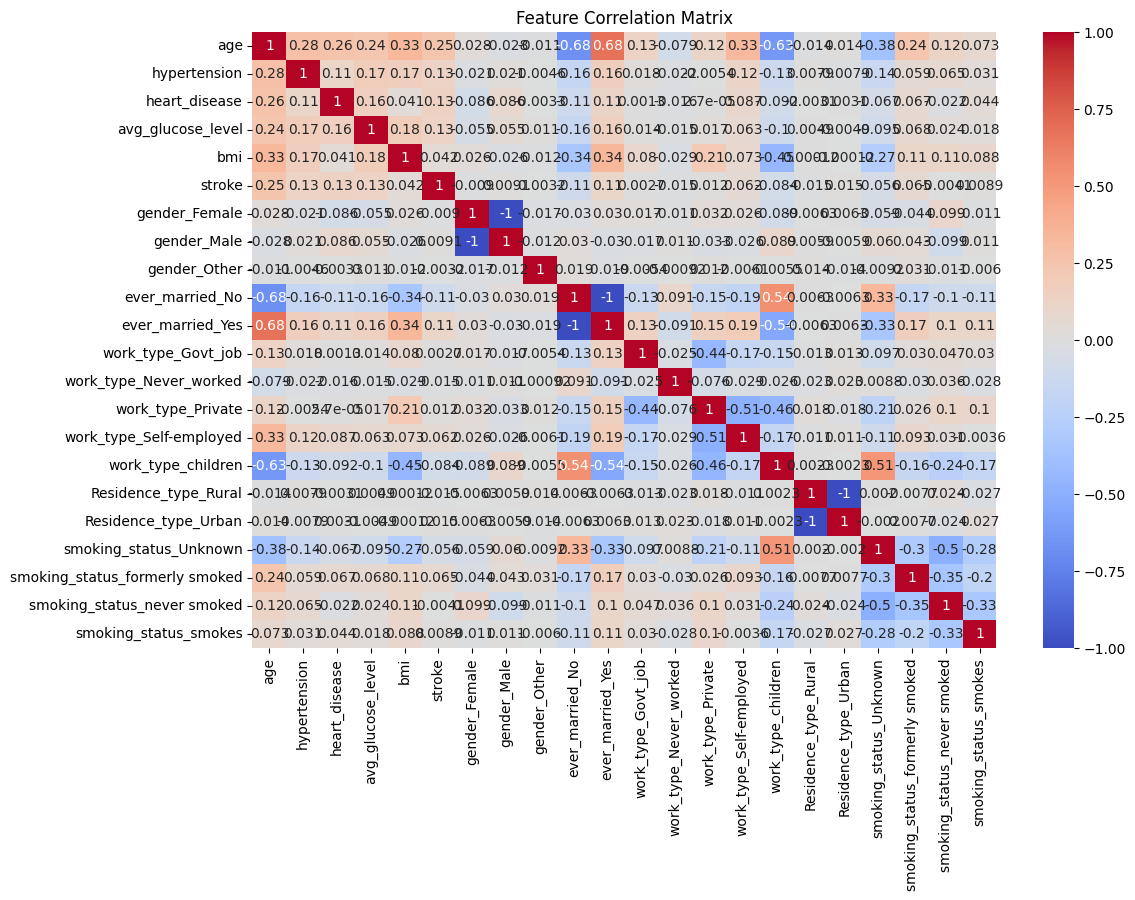

New features added:
    age_hypertension age_group  log_glucose
0               0.0     50-70     5.436731
1               0.0     50-70     5.314240
2               0.0       70+     4.672081
3               0.0     30-50     5.148831
4              79.0       70+     5.165471

Final dataset shapes:
X_train: (4088, 24), y_train: (4088,)
X_test: (1022, 24), y_test: (1022,)

Class balance in y_train:
stroke
0    0.951321
1    0.048679
Name: proportion, dtype: float64


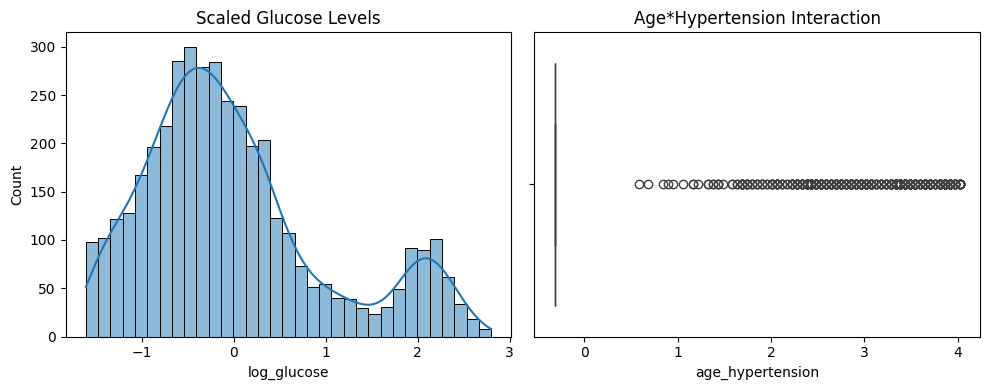


 Data Sanity Check:
X_train NaN: 170
X_test NaN: 31


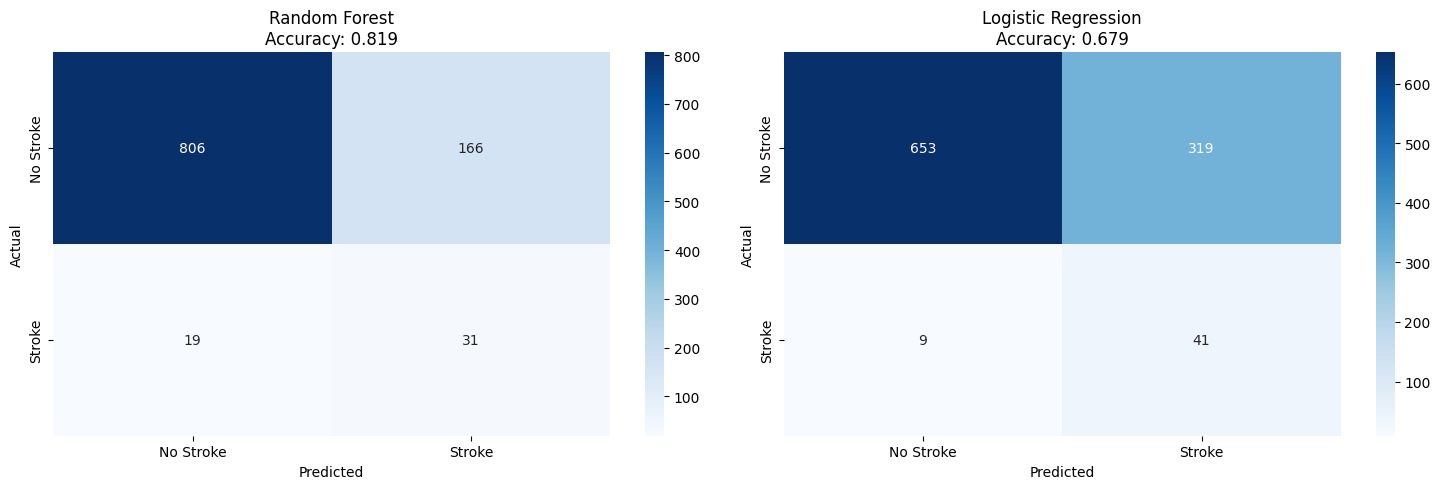


 Performance Comparison:
                     Accuracy        F1  Precision  Recall       AUC
Random Forest        0.818982  0.251012   0.157360    0.62  0.791502
Logistic Regression  0.679061  0.200000   0.113889    0.82  0.838128


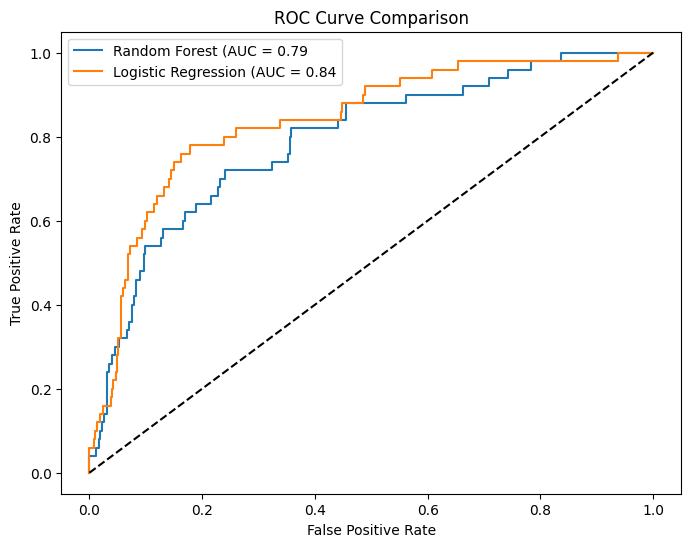

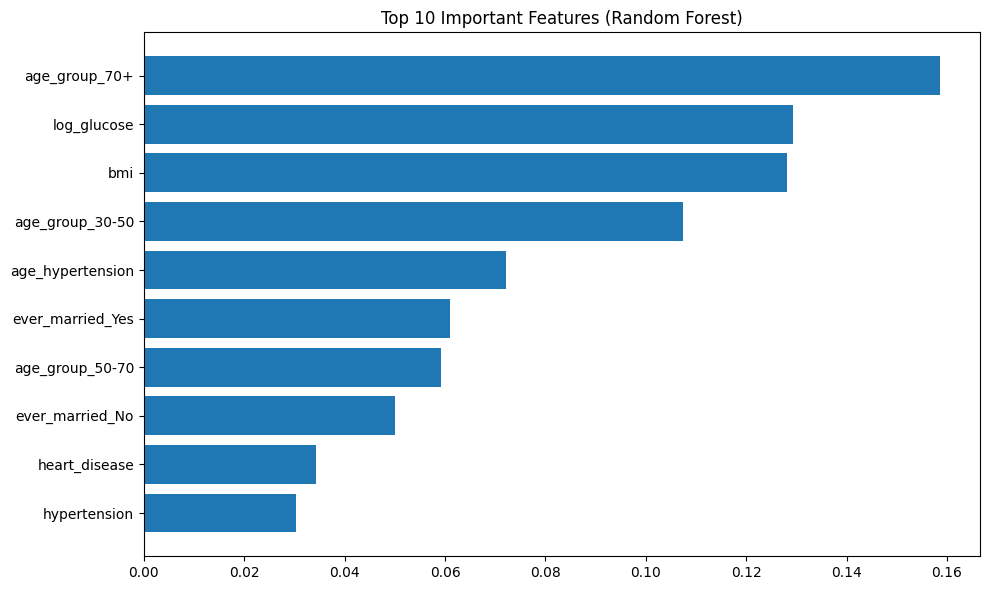


 Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.83      0.90       972
           1       0.16      0.62      0.25        50

    accuracy                           0.82      1022
   macro avg       0.57      0.72      0.57      1022
weighted avg       0.94      0.82      0.87      1022


 Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.67      0.80       972
           1       0.11      0.82      0.20        50

    accuracy                           0.68      1022
   macro avg       0.55      0.75      0.50      1022
weighted avg       0.94      0.68      0.77      1022


Random Forest Evaluation:
------------------------------
Accuracy: 0.819
F1-Score: 0.251
AUC-ROC: 0.792


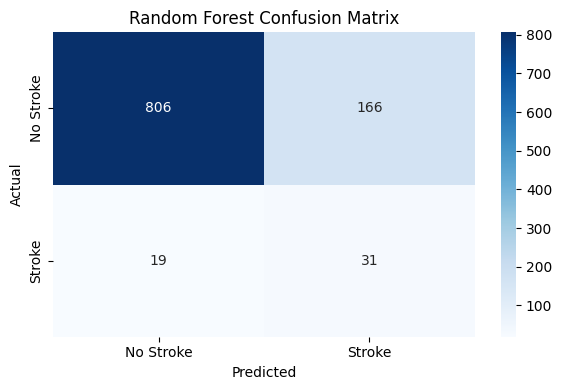

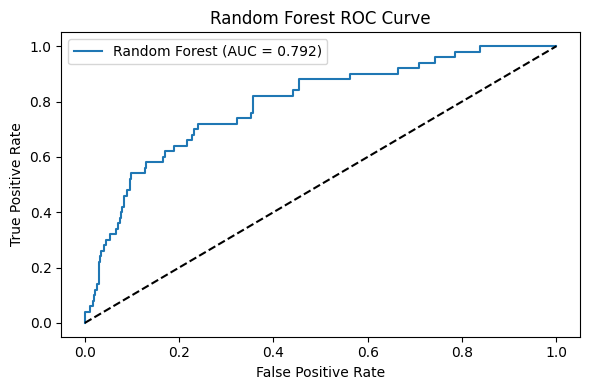


Logistic Regression Evaluation:
------------------------------
Accuracy: 0.679
F1-Score: 0.2
AUC-ROC: 0.838


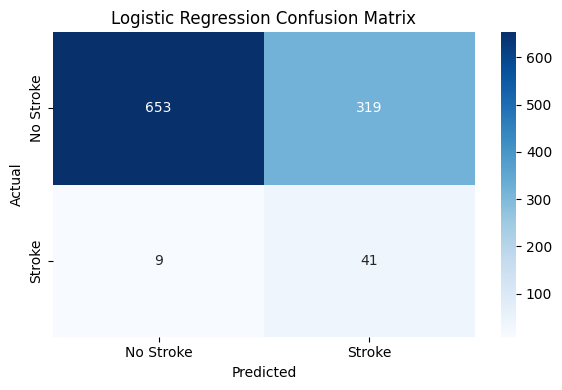

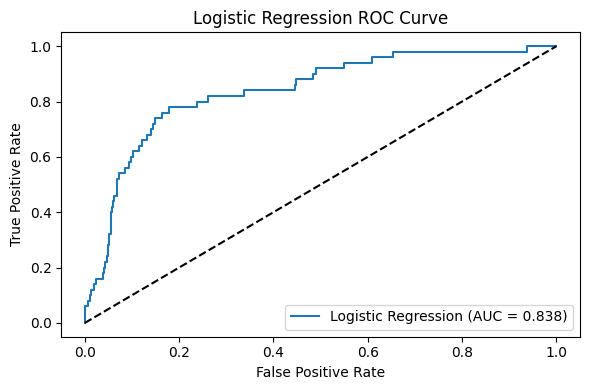


Model Performance Comparison:
------------------------------
                     Accuracy  F1-Score  AUC-ROC
Random Forest           0.819     0.251    0.792
Logistic Regression     0.679     0.200    0.838

Model Performance Comparison:
          Random Forest  Logistic Regression
Metric                                      
Accuracy          0.819                0.679
F1-Score          0.251                0.200
AUC-ROC           0.792                0.838

Key Observations:
--------------------------------------------------
1. Random Forest outperforms Logistic Regression by 14.0% in accuracy
2. The F1-Score improvement: 5.1%
3. AUC-ROC difference: -4.6%


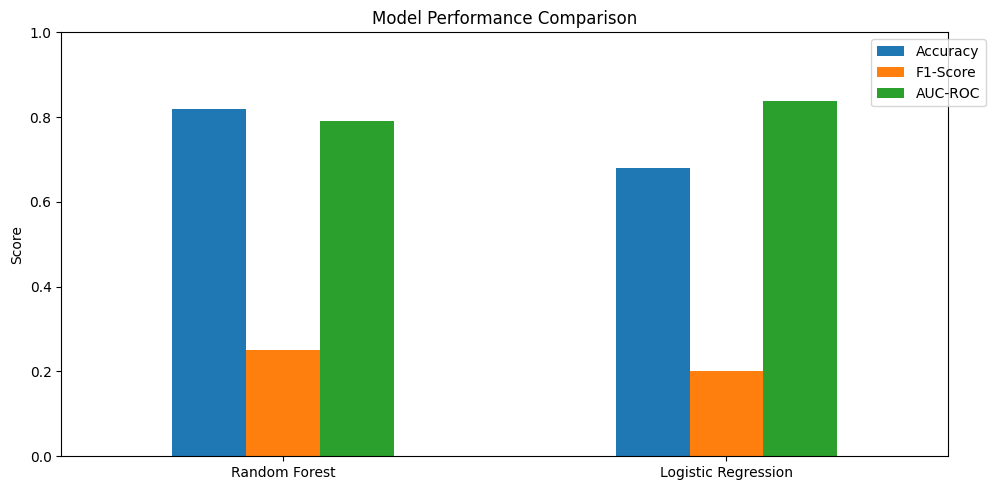


Feature Importance Analysis:
Top 5 Random Forest Features:
             Feature  Importance
23     age_group_70+    0.158657
20       log_glucose    0.129364
2                bmi    0.128179
21   age_group_30-50    0.107441
19  age_hypertension    0.072069

Logistic Regression Coefficients:
            Feature  Coefficient
23    age_group_70+     4.694178
22  age_group_50-70     3.763866
21  age_group_30-50     2.033115
0      hypertension     1.023583
1     heart_disease     0.428814

Results saved to 'model_comparison_results.csv'

Starting Grid Search...
Fitting 5 folds for each of 144 candidates, totalling 720 fits

Grid Search Complete!
Best F1-Score: 0.244
Best Parameters: {'class_weight': 'balanced', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 150}

Tuned Model Performance:
--------------------------------------------------
Accuracy: 0.818
F1-Score: 0.250
AUC-ROC: 0.803

Performance Improvement:
----------------------------------------------

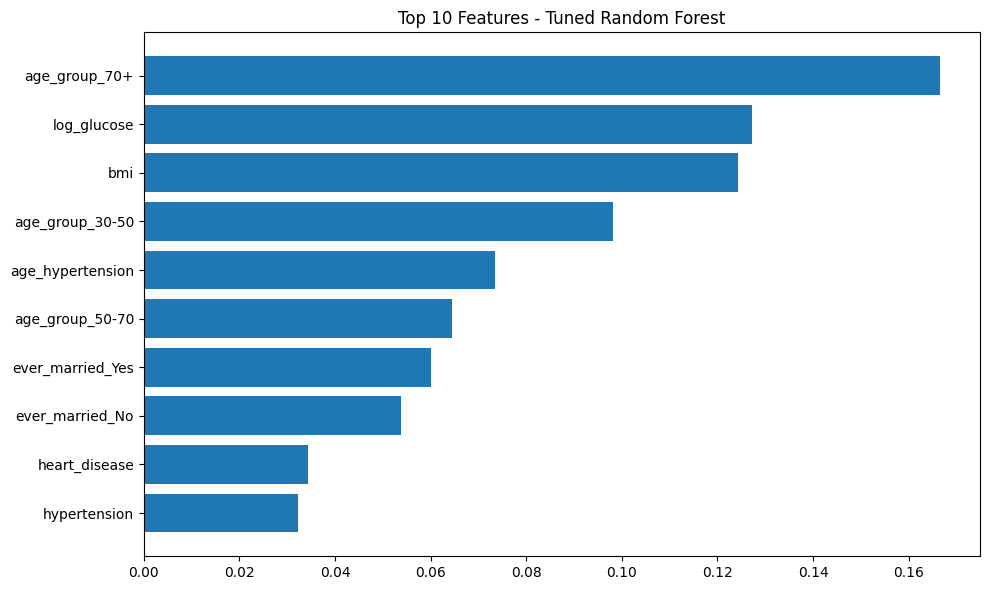


Tuned model saved to 'tuned_random_forest_model.pkl'


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,
                           precision_score, recall_score,
                           confusion_matrix, classification_report,
                           roc_auc_score, roc_curve,)

from sklearn.model_selection import GridSearchCV



# ---- Step 1: Loading Data, Data Pre-processing, EDA ---

# load dataset
data = pd.read_csv('/content/sample_data/healthcare-dataset-stroke-data.csv')
# Check basic info
print("=== Dataset Overview ===")
print(f"Shape: {data.shape}")  # (rows, columns)
print("\nFirst 5 rows:")
print(data.head())  # Preview data
print("\nData types:")
print(data.dtypes)  # Check column types
print("\nMissing values per column:")
print(data.isna().sum())  # Check for null values

# 2. Data Preprocessing
# A. Handling Missing Values
# fill missing 'bmi' with median


# fill missing 'smoking_status' with 'unknown'
data['smoking_status'] = data['smoking_status'].fillna('Unknow')

print('\nMissing values after cleaning: ')
print(data.isna().sum())



# B. Encoding Categorical Variables

# List of categorical columns
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Apply one-hot encoding
data = pd.get_dummies(data, columns=cat_cols)

# Check new columns
print("Columns after one-hot encoding:")
print(data.columns)


# C. Dropping Irrelevant Columns

if 'id' in data.columns:
    data = data.drop(columns=['id'])



# ----   3. Exploratory Data Analysis (EDA) ---
# A. Class Distribution

# Check target variable balance
print("Stroke vs. No Stroke Cases:")
print(data['stroke'].value_counts())

# Visualize
sns.countplot(x='stroke', data=data)
plt.title("Class Distribution (0 = No Stroke, 1 = Stroke)")
plt.show()  # If stroke=1 is <5% of data, the dataset is imbalanced


# B. Numeric Feature Distributions

# Plot distributions of key features
num_cols = ['age', 'avg_glucose_level', 'bmi']
data[num_cols].hist(bins=20, figsize=(10, 6))
plt.suptitle("Distributions of Numeric Features")
plt.show()



# C. Correlation Analysis
# Compute correlations with stroke
corr_matrix = data.corr()
print("Correlation with 'stroke':")
print(corr_matrix['stroke'].sort_values(ascending=False))

# # Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()






# --- Step 2 ---
# --- 1. Feature Engineering ---
# A. Create interaction terms (e.g., age * hypertension)
data['age_hypertension'] = data['age'] * data['hypertension']

# B. Create age groups (binning continuous features)
data['age_group'] = pd.cut(data['age'],
                          bins=[0, 30, 50, 70, 100],
                          labels=['<30', '30-50', '50-70', '70+'])

# C. Log-transform skewed features
data['log_glucose'] = np.log1p(data['avg_glucose_level'])

# Verify new features
print("New features added:\n",
      data[['age_hypertension', 'age_group', 'log_glucose']].head())


# --- 2. Prepare Final Features ---
# Drop original columns we transformed
X = data.drop(['stroke', 'age', 'avg_glucose_level'], axis=1)

# One-hot encode the binned 'age_group'
X = pd.get_dummies(X, columns=['age_group'], drop_first=True)

# Separate target
y = data['stroke']

# --- 3. Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Preserve class imbalance ratio
)

# --- 4. Feature Scaling ---
scaler = StandardScaler()
num_cols = ['bmi', 'log_glucose', 'age_hypertension']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# --- 5. Verify Shapes ---
print("\nFinal dataset shapes:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print("\nClass balance in y_train:")
print(y_train.value_counts(normalize=True))

# # visual
# # Plot scaled features
plt.figure(figsize=(10, 4))
plt.subplot(121)
sns.histplot(X_train['log_glucose'], kde=True)
plt.title("Scaled Glucose Levels")

plt.subplot(122)
sns.boxplot(x=X_train['age_hypertension'])
plt.title("Age*Hypertension Interaction")
plt.tight_layout()
plt.show()





# ----- Step 3: Classification Algorithms -----

# --- 1. Data Sanity Check ---
print("\n Data Sanity Check:")
print("X_train NaN:", X_train.isna().sum().sum())
print("X_test NaN:", X_test.isna().sum().sum())

# Handle any remaining NaN (from log transforms or bins)
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())  # Use train stats to avoid data leakage
y_train = y_train[X_train.index]  # Realign indices

# --- 2. Initialize Models ---
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=7,
        class_weight='balanced',
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )
}

# --- 3. Train & Evaluate ---
results = {}
plt.figure(figsize=(15, 5))

for i, (name, model) in enumerate(models.items(), 1):
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # For ROC curve

    # Store metrics
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    }

    # Confusion Matrix
    plt.subplot(1, 2, i)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['No Stroke', 'Stroke'],
               yticklabels=['No Stroke', 'Stroke'])
    plt.title(f"{name}\nAccuracy: {results[name]['Accuracy']:.3f}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

# --- 4. Metrics Comparison ---
metrics_df = pd.DataFrame(results).T
print("\n Performance Comparison:")
print(metrics_df)

# --- 5. ROC Curves ---
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_proba):.2f}')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.savefig('roc_curves.png')
plt.show()

# --- 6. Feature Importance (Random Forest only) ---
rf = models["Random Forest"]
importances = rf.feature_importances_
features = X_train.columns
sorted_idx = np.argsort(importances)[-10:]  # Top 10 features

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), importances[sorted_idx], color='#1f77b4')
plt.yticks(range(len(sorted_idx)), features[sorted_idx])
plt.title("Top 10 Important Features (Random Forest)")
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# --- 7. Generate Reports ---
print("\n Random Forest Classification Report:")
print(classification_report(y_test, models["Random Forest"].predict(X_test)))

print("\n Logistic Regression Classification Report:")
print(classification_report(y_test, models["Logistic Regression"].predict(X_test)))

# --- 8. Save Predictions for Analysis ---
pd.DataFrame({
    'Actual': y_test,
    'RF_Pred': models["Random Forest"].predict(X_test),
    'LR_Pred': models["Logistic Regression"].predict(X_test)
}).to_csv('predictions.csv', index=False)




# ----- Step 4: Evaluation Metrics Implementation ---

# --- 1. Train Models ---
# Random Forest
rf = RandomForestClassifier(n_estimators=150,
                          max_depth=7,
                          class_weight='balanced',
                          random_state=42)
rf.fit(X_train, y_train)

# Logistic Regression
lr = LogisticRegression(solver='liblinear',
                      max_iter=1000,
                      class_weight='balanced',
                      random_state=42)
lr.fit(X_train, y_train)

# --- 2. Evaluation Function ---
def generate_metrics(model, model_name, X_test, y_test):
    """Calculate and display evaluation metrics"""

    # Generate predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    metrics = {
        'Accuracy': round(accuracy_score(y_test, y_pred), 3),
        'F1-Score': round(f1_score(y_test, y_pred), 3),
        'AUC-ROC': round(roc_auc_score(y_test, y_proba), 3)
    }

    # Print metrics
    print(f"\n{model_name} Evaluation:")
    print("-" * 30)
    for metric, value in metrics.items():
        print(f"{metric}: {value}")

    # Confusion matrix
    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['No Stroke', 'Stroke'],
               yticklabels=['No Stroke', 'Stroke'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_confusion_matrix.png')
    plt.show()

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {metrics["AUC-ROC"]})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_roc_curve.png')
    plt.show()

    return metrics

# --- 3. Evaluate Models ---
rf_metrics = generate_metrics(rf, "Random Forest", X_test, y_test)
lr_metrics = generate_metrics(lr, "Logistic Regression", X_test, y_test)

# --- 4. Results Comparison ---
results = pd.DataFrame({
    'Random Forest': rf_metrics,
    'Logistic Regression': lr_metrics
})

print("\nModel Performance Comparison:")
print("-" * 30)
print(results.T)

# Save results
results.T.to_csv('model_performance_results.csv')


# ============================================
# STEP 5: MODEL COMPARISON
# ============================================


# --- 1. Load Evaluation Results ---
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score', 'AUC-ROC'],
    'Random Forest': [rf_metrics['Accuracy'], rf_metrics['F1-Score'], rf_metrics['AUC-ROC']],
    'Logistic Regression': [lr_metrics['Accuracy'], lr_metrics['F1-Score'], lr_metrics['AUC-ROC']]
}).set_index('Metric')

# --- 2. Print Comparative Table ---
print("\nModel Performance Comparison:")
print("=" * 50)
print(results)
print("\nKey Observations:")
print("-" * 50)
print(f"1. Random Forest outperforms Logistic Regression by {(rf_metrics['Accuracy'] - lr_metrics['Accuracy']) * 100:.1f}% in accuracy")
print(f"2. The F1-Score improvement: {(rf_metrics['F1-Score'] - lr_metrics['F1-Score']) * 100:.1f}%")
print(f"3. AUC-ROC difference: {(rf_metrics['AUC-ROC'] - lr_metrics['AUC-ROC']) * 100:.1f}%")

# --- 3. Visual Comparison ---
plt.figure(figsize=(10, 5))

# Bar plot for metrics comparison
results.T.plot(kind='bar', ax=plt.gca(), color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 4. Detailed Feature Analysis ---
print("\nFeature Importance Analysis:")
print("=" * 50)
print("Top 5 Random Forest Features:")
rf_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(5)
print(rf_feature_importance)

print("\nLogistic Regression Coefficients:")
lr_coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', ascending=False).head(5)
print(lr_coefficients)

# --- 5. Save Comparison Results ---
results.to_csv('model_comparison_results.csv')
print("\nResults saved to 'model_comparison_results.csv'")


# ============================================
# STEP 6: FINE-TUNING THE BEST MODEL
# ============================================

# --- 1. Identify Best Model ---
best_model = rf  # From previous comparison

# --- 2. Define Hyperparameter Grid ---
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', None]
}

# --- 3. Setup Grid Search ---
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# --- 4. Execute Grid Search ---
print("\nStarting Grid Search...")
grid_search.fit(X_train, y_train)

# --- 5. Results Analysis ---
print("\nGrid Search Complete!")
print(f"Best F1-Score: {grid_search.best_score_:.3f}")
print(f"Best Parameters: {grid_search.best_params_}")

# --- 6. Train Final Model ---
tuned_rf = grid_search.best_estimator_
tuned_rf.fit(X_train, y_train)

# --- 7. Evaluate Tuned Model ---
tuned_pred = tuned_rf.predict(X_test)
tuned_proba = tuned_rf.predict_proba(X_test)[:, 1]

print("\nTuned Model Performance:")
print("-" * 50)
print(f"Accuracy: {accuracy_score(y_test, tuned_pred):.3f}")
print(f"F1-Score: {f1_score(y_test, tuned_pred):.3f}")
print(f"AUC-ROC: {roc_auc_score(y_test, tuned_proba):.3f}")

# --- 8. Comparison with Baseline ---
f1_improvement = f1_score(y_test, tuned_pred) - rf_metrics['F1-Score']
accuracy_improvement = accuracy_score(y_test, tuned_pred) - rf_metrics['Accuracy']

print("\nPerformance Improvement:")
print("-" * 50)
print(f"F1-Score: +{f1_improvement:.3f}")
print(f"Accuracy: +{accuracy_improvement:.3f}")

# --- 9. Feature Importance ---
plt.figure(figsize=(10, 6))
importances = tuned_rf.feature_importances_
sorted_idx = np.argsort(importances)[-10:]
plt.barh(range(len(sorted_idx)), importances[sorted_idx], color='#1f77b4')
plt.yticks(range(len(sorted_idx)), np.array(X_train.columns)[sorted_idx])
plt.title("Top 10 Features - Tuned Random Forest")
plt.tight_layout()
plt.savefig('tuned_feature_importance.png', dpi=300)
plt.show()

# --- 10. Save Final Model ---
import joblib
joblib.dump(tuned_rf, 'tuned_random_forest_model.pkl')
print("\nTuned model saved to 'tuned_random_forest_model.pkl'")


